In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
import seaborn as sns
from sklearn.decomposition import PCA, KernelPCA
from sklearn import manifold
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)

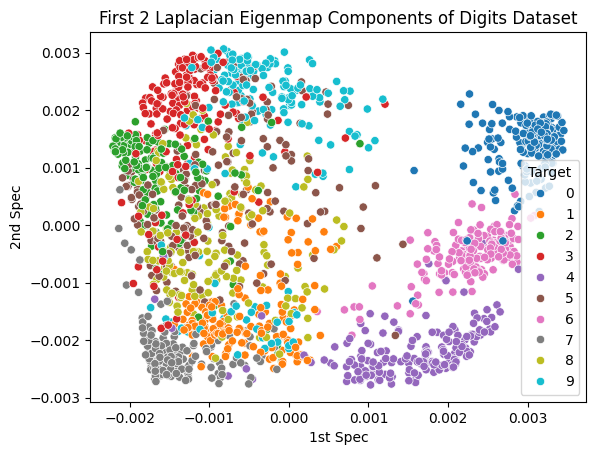

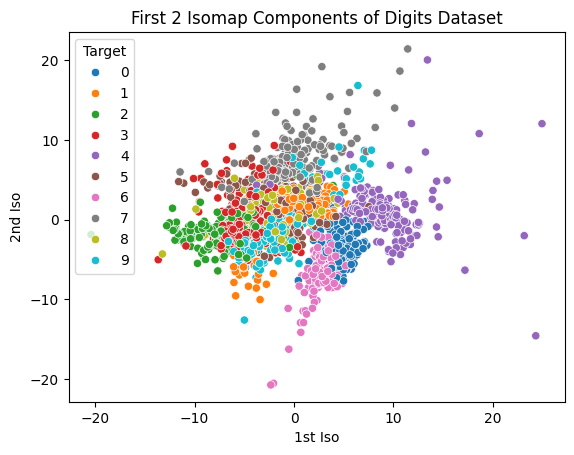

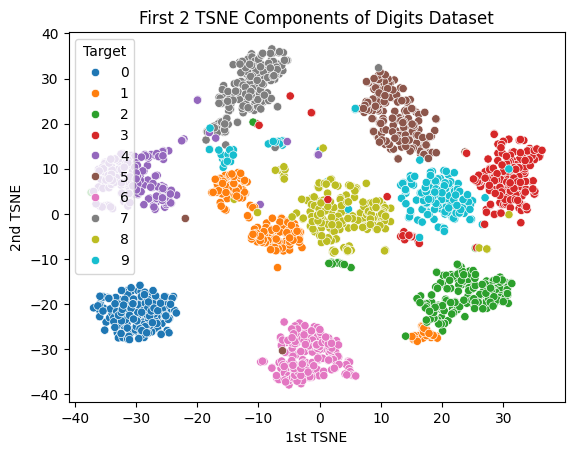

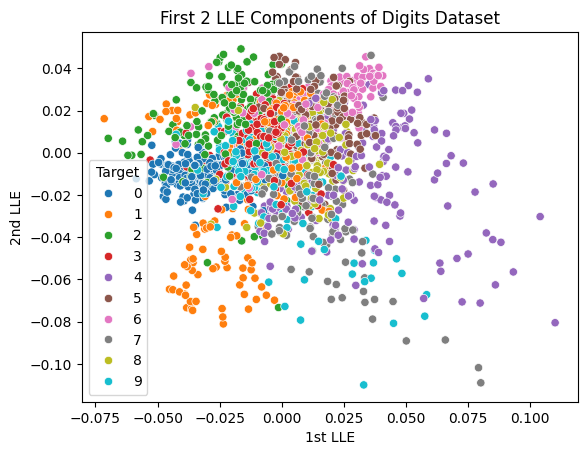

In [11]:
spec = make_pipeline(StandardScaler(), manifold.SpectralEmbedding(n_neighbors=200, random_state=0))
X_spec = spec.fit_transform(X)

iso = make_pipeline(StandardScaler(), manifold.Isomap(n_neighbors=200))
X_iso = iso.fit_transform(X)

tsne = make_pipeline(StandardScaler(), manifold.TSNE(perplexity = 50, random_state = 0))
X_tsne = tsne.fit_transform(X)

lle = make_pipeline(StandardScaler(), manifold.LocallyLinearEmbedding(n_neighbors = 200, random_state = 0))
X_lle = lle.fit_transform(X)

df_spec = pd.DataFrame(data=X_spec[:, :2], columns=['1st Spec','2nd Spec'])
df_spec['Target'] = y
sns.scatterplot(data=df_spec, x="1st Spec", y="2nd Spec", hue="Target", palette='tab10')
plt.title('First 2 Laplacian Eigenmap Components of Digits Dataset')
plt.show()

df_iso = pd.DataFrame(data=X_iso[:, :2], columns=['1st Iso','2nd Iso'])
df_iso['Target'] = y
sns.scatterplot(data=df_iso, x="1st Iso", y="2nd Iso", hue="Target", palette='tab10')
plt.title('First 2 Isomap Components of Digits Dataset')
plt.show()

df_tsne = pd.DataFrame(data=X_tsne[:, :2], columns=['1st TSNE','2nd TSNE'])
df_tsne['Target'] = y
sns.scatterplot(data=df_tsne, x="1st TSNE", y="2nd TSNE", hue="Target", palette='tab10')
plt.title('First 2 TSNE Components of Digits Dataset')
plt.show()

df_lle = pd.DataFrame(data=X_lle[:, :2], columns=['1st LLE','2nd LLE'])
df_lle['Target'] = y
sns.scatterplot(data=df_lle, x="1st LLE", y="2nd LLE", hue="Target", palette='tab10')
plt.title('First 2 LLE Components of Digits Dataset')
plt.show()



A. Which methods produced clear clusters?

Of all the methods, t-SNE produced the cleanest clusters. Isomap had good separation but only over a small area. The Laplacian Eigenmap and KPCA was able to separate digits 0, 4, and 6 quite well but struggled with the others. PCA did okay, but LLE struggled the most.

Components for ≥95% CPV: 40


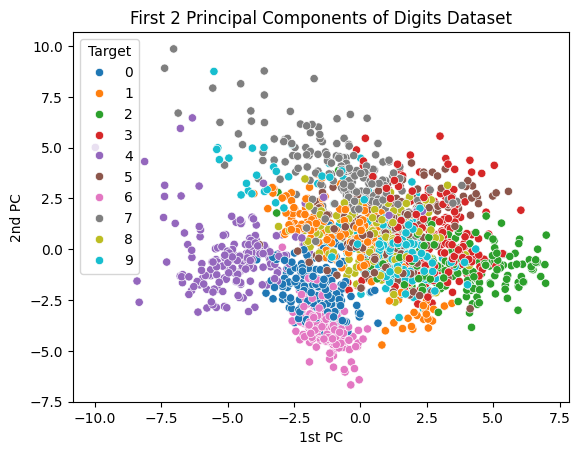

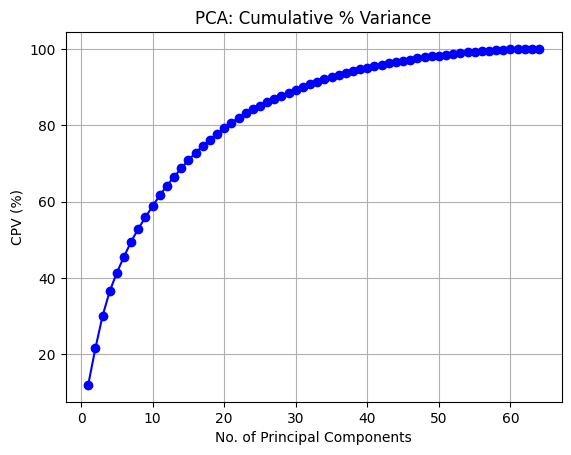

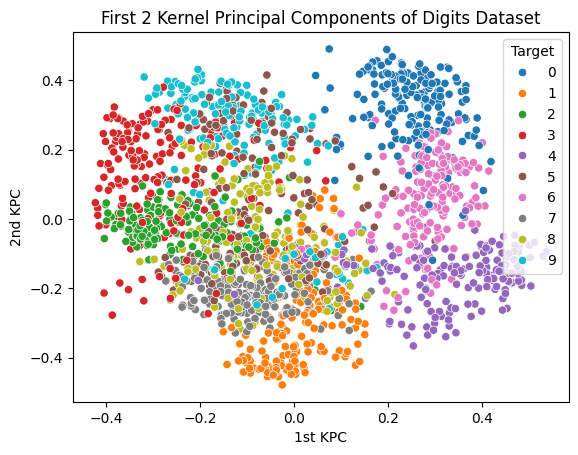

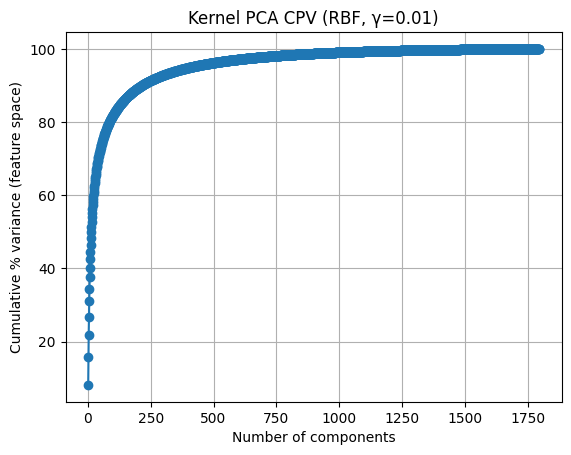

Components for ≥95% CPV: 408


In [15]:
# Perform Standard Scaling then PCA
pca = make_pipeline(StandardScaler(), PCA())
X_pca = pca.fit(X).transform(X)
var = pca[1].explained_variance_ratio_
cpv = np.cumsum(var)*100
k95 = int(np.searchsorted(cpv, 95) + 1)
print(f'Components for ≥95% CPV: {k95}')

# Plot the first 2 principal components
df = pd.DataFrame(data=X_pca[:, :2], columns=['1st PC','2nd PC'])
df['Target'] = y
sns.scatterplot(data=df, x="1st PC", y="2nd PC", hue="Target", palette='tab10')
plt.title('First 2 Principal Components of Digits Dataset')
plt.show()

# Plot the Cumulative Percent Variance
plt.plot(np.arange(cpv.size)+1,cpv,'bo-')
plt.title('PCA: Cumulative % Variance')
plt.xlabel('No. of Principal Components')
plt.ylabel('CPV (%)')
plt.grid()
plt.show()

# --- your existing code ---
kpca = make_pipeline(StandardScaler(), KernelPCA(kernel='rbf', gamma=0.01))
X_kpca = kpca.fit(X).transform(X)
df_kpca = pd.DataFrame(data=X_kpca[:, :2], columns=['1st KPC','2nd KPC'])

df_kpca['Target'] = y
sns.scatterplot(data=df_kpca, x="1st KPC", y="2nd KPC", hue="Target", palette='tab10')
plt.title('First 2 Kernel Principal Components of Digits Dataset')
plt.show()

# --- CPV for Kernel PCA (feature-space variance) ---
# Reuse the fitted scaler from your pipeline
scaler = kpca.named_steps['standardscaler']
X_scaled = scaler.transform(X)

# Fit KPCA again with ALL components to get eigenvalues of the centered kernel
kpca_full = KernelPCA(kernel='rbf', gamma=0.01, n_components=None, eigen_solver='auto')
kpca_full.fit(X_scaled)

# Eigenvalues (a.k.a. lambdas of the centered Gram matrix)
# USED COPILOT HERE #
lmbda = getattr(kpca_full, 'lambdas_', getattr(kpca_full, 'eigenvalues_', None))
lmbda = np.clip(lmbda, 0, None)        # guard against tiny negative round-off

# Explained variance ratio & CPV
evr = lmbda / lmbda.sum()
cpv = np.cumsum(evr) * 100

# Plot CPV
plt.figure()
plt.plot(np.arange(1, len(cpv)+1), cpv, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative % variance (feature space)')
plt.title('Kernel PCA CPV (RBF, γ=0.01)')
plt.grid(True)
plt.show()

# How many components to reach a target CPV (e.g., 95%)?
k95 = int(np.searchsorted(cpv, 95) + 1)
print(f'Components for ≥95% CPV: {k95}')


B. Report the CPV plot and determine the number of PCs for >= 95% CPV

To retain 95% CPV for PCA, we need 40 components. For Kernel PCA with RBF kernel (gamma=0.01), we need 406 components to reach >= 95% CPV. The CPV plots for both PCA and KPCA are shown above.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5, stratify=y)

kpca = make_pipeline(StandardScaler(), KernelPCA(kernel = 'sigmoid',n_components=40), SVC())
kpca.fit(X_train, y_train)
y_pred_kpca = kpca.predict(X_test)
print(classification_report(y_test, y_pred_kpca))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.98      1.00      0.99        55
           2       1.00      1.00      1.00        53
           3       1.00      0.98      0.99        55
           4       1.00      1.00      1.00        54
           5       1.00      0.96      0.98        55
           6       0.98      0.98      0.98        54
           7       1.00      0.98      0.99        54
           8       0.98      1.00      0.99        52
           9       0.96      1.00      0.98        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.92      0.98      0.95        55
           2       0.96      0.98      0.97        53
           3       0.98 



To retain 95% CPV for PCA and KPCA

“Can we extract more than 9 components from LDA? Why/why not?”
No. With C classes, LDA gives at most C−1 components; with 10 digits, max is 9.

Best classifier = KPCA(‘sigmoid’,40)→SVC (acc≈0.99, F1≈0.99). 